In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


In [7]:
OUTPUT_DIR = "../outputs/evaluation"

y_true = np.load(f"{OUTPUT_DIR}/y_true.npy")
y_pred = np.load(f"{OUTPUT_DIR}/y_pred.npy")
y_prob = np.load(f"{OUTPUT_DIR}/y_prob.npy")
cm = np.load(f"{OUTPUT_DIR}/confusion_matrix.npy")

with open(f"{OUTPUT_DIR}/class_names.txt") as f:
    class_names = [line.strip() for line in f]

num_classes = len(class_names)


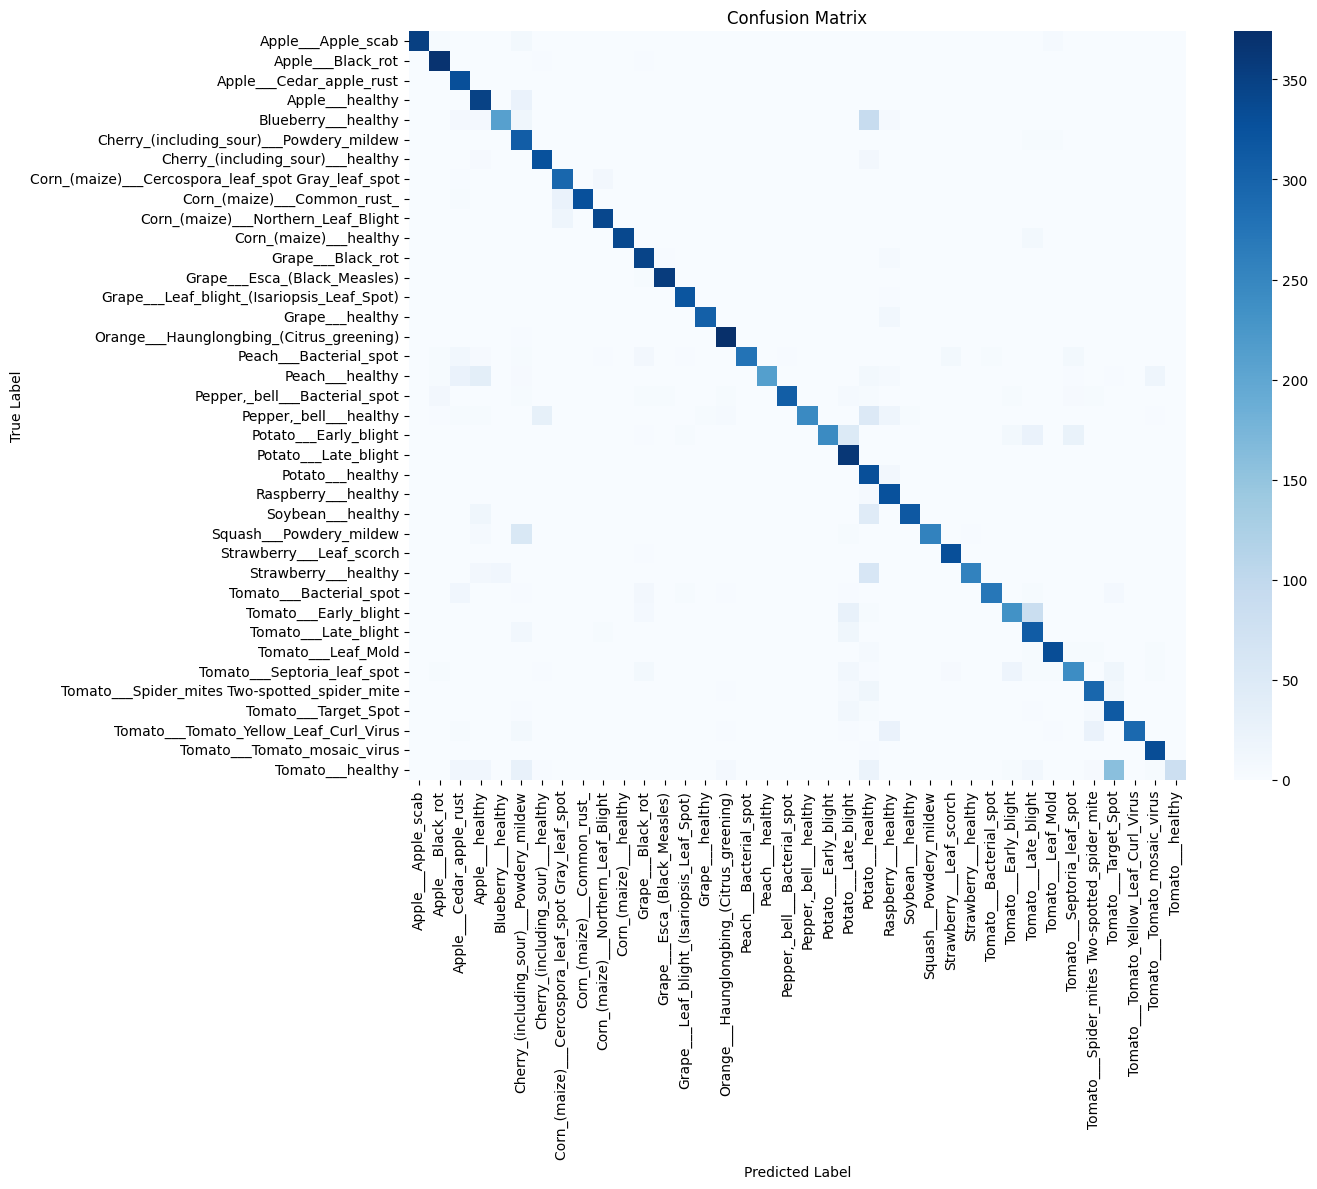

In [8]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=False
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


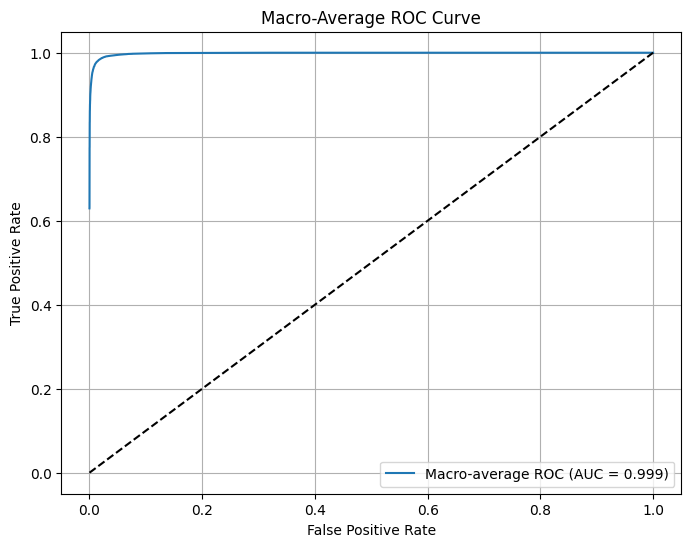

In [9]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))

fpr = dict()
tpr = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(8, 6))
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


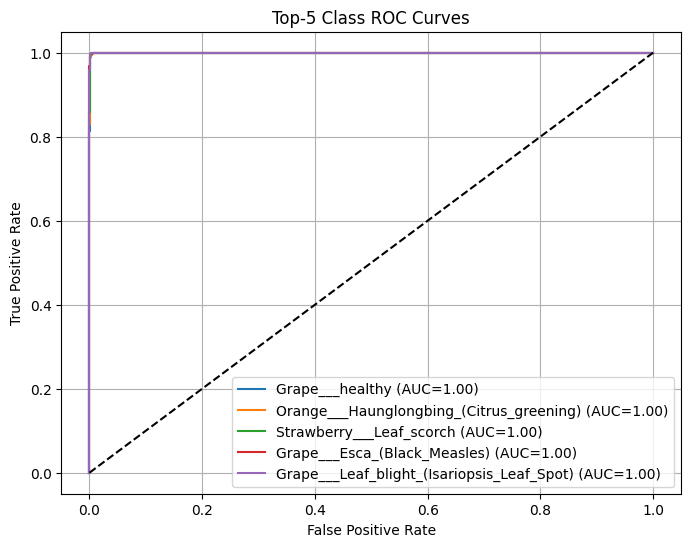

In [10]:
from sklearn.metrics import roc_auc_score

auc_scores = [
    roc_auc_score(y_true_bin[:, i], y_prob[:, i])
    for i in range(num_classes)
]

top_classes = np.argsort(auc_scores)[-5:]

plt.figure(figsize=(8, 6))

for i in top_classes:
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    plt.plot(fpr_i, tpr_i, label=f"{class_names[i]} (AUC={auc_scores[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Top-5 Class ROC Curves")
plt.legend()
plt.grid(True)
plt.show()
